# PCA & Dimensionality Reduction

In [14]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from mindmetrix_biomarker.loader import load_data
from mindmetrix_biomarker.preprocess import preprocess_physiological_data, preprocess_subjects_data, check_subjects_in_datasets
from mindmetrix_biomarker.exctract import extract_features

sns.set_style("whitegrid")

## 1. Load data

In [15]:
data_path = Path("../data/raw/timeseries.csv")
subjects_data_path = Path("../data/raw/subjects.csv")

physiological_df = load_data(data_path)
preprocessed_physiological_df = preprocess_physiological_data(physiological_df)
subjects_df = load_data(subjects_data_path)
preprocessed_subjects_df = preprocess_subjects_data(subjects_df)
missing_in_physiological, missing_in_subjects = check_subjects_in_datasets(preprocessed_physiological_df, preprocessed_subjects_df)
preprocessed_subjects_df = preprocessed_subjects_df[~preprocessed_subjects_df["SubjectID"].isin(missing_in_physiological)]
preprocessed_physiological_df = preprocessed_physiological_df[~preprocessed_physiological_df["SubjectID"].isin(missing_in_subjects)]
# Extract features
all_features = extract_features(preprocessed_physiological_df, preprocessed_subjects_df)

Preprocessing physiological data...
Validating data schema...
Delete duplicates done.
Delete implausible values and low quality signals done.
Filter by angles done.
Preprocessing physiological data done.
Preprocessing subjects data...
Delete duplicates done.
Preprocessing subjects data done.
Extracting features...
Features extracted successfully.


In [16]:
# all_features = pd.read_csv("../data/extracted/all_features.csv", index_col=0)
print("Shape:", all_features.shape)

# Separate metadata from numeric features
metadata_cols = ["STAI_T", "STAI_S", "Gender", "Handedness", "WearsGlasses", "CalibrationError", "BloodType"]
feature_cols = [c for c in all_features.select_dtypes(include=np.number).columns if c not in metadata_cols]

print(f"\nNumeric features for PCA: {len(feature_cols)}")
print(f"Metadata columns kept aside: {metadata_cols}")

X = all_features[feature_cols].dropna()
metadata = all_features.loc[X.index, metadata_cols]
print(f"\nSubjects after dropping NaN: {len(X)}")

Shape: (495, 97)

Numeric features for PCA: 90
Metadata columns kept aside: ['STAI_T', 'STAI_S', 'Gender', 'Handedness', 'WearsGlasses', 'CalibrationError', 'BloodType']

Subjects after dropping NaN: 493


## 2. Standardization

PCA is sensitive to the scale of features.

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Verify: each column should now have mean ~0 and std ~1
print("Mean per feature (should be ~0):", X_scaled.mean(axis=0).round(6)[:5], "...")
print("Std per feature (should be ~1):", X_scaled.std(axis=0).round(6)[:5], "...")

Mean per feature (should be ~0): [-0. -0.  0.  0. -0.] ...
Std per feature (should be ~1): [1. 1. 1. 1. 1.] ...


## 3. Fit PCA (all components)


In [18]:
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

print(f"Total components: {pca_full.n_components_}")
print(f"\nVariance explained by first 5 PCs:")
for i in range(5):
    print(f"  PC{i+1}: {pca_full.explained_variance_ratio_[i]*100:.2f}%")
print(f"  ...")
print(f"  Total (first 5): {sum(pca_full.explained_variance_ratio_[:5])*100:.1f}%")

Total components: 90

Variance explained by first 5 PCs:
  PC1: 14.67%
  PC2: 10.78%
  PC3: 8.00%
  PC4: 7.66%
  PC5: 6.55%
  ...
  Total (first 5): 47.7%


## 4. Scree plot: how many components do we need?

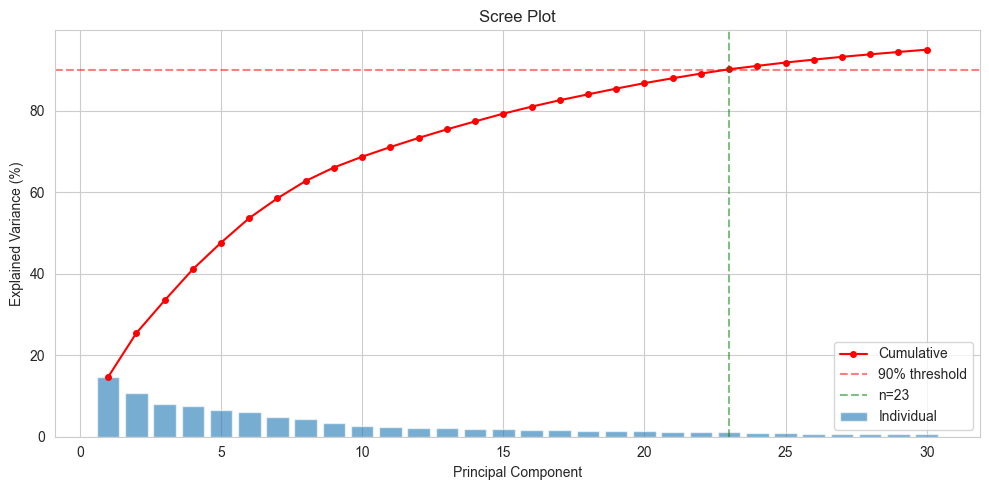


Components needed for 90% variance: 23
Components needed for 95% variance: 30


In [19]:
explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)
n_for_90 = int(np.argmax(cumulative >= 0.90) + 1)

fig, ax = plt.subplots(figsize=(10, 5))

n_show = min(30, len(explained))
x = range(1, n_show + 1)

ax.bar(x, explained[:n_show] * 100, alpha=0.6, label="Individual")
ax.plot(x, cumulative[:n_show] * 100, "ro-", markersize=4, label="Cumulative")
ax.axhline(90, color="red", linestyle="--", alpha=0.5, label="90% threshold")
ax.axvline(n_for_90, color="green", linestyle="--", alpha=0.5, label=f"n={n_for_90}")

ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance (%)")
ax.set_title("Scree Plot")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nComponents needed for 90% variance: {n_for_90}")
print(f"Components needed for 95% variance: {int(np.argmax(cumulative >= 0.95) + 1)}")

## 4. PCA with selected number of components

In [20]:
pca = PCA(n_components=n_for_90)
X_pca = pca.fit_transform(X_scaled)

print(f"Original dimensions: {X_scaled.shape[1]}")
print(f"Reduced dimensions:  {X_pca.shape[1]}")
print(f"Variance retained:   {sum(pca.explained_variance_ratio_)*100:.1f}%")

Original dimensions: 90
Reduced dimensions:  23
Variance retained:   90.2%


## 5. 2D projection: subjects in PC1 vs PC2 space

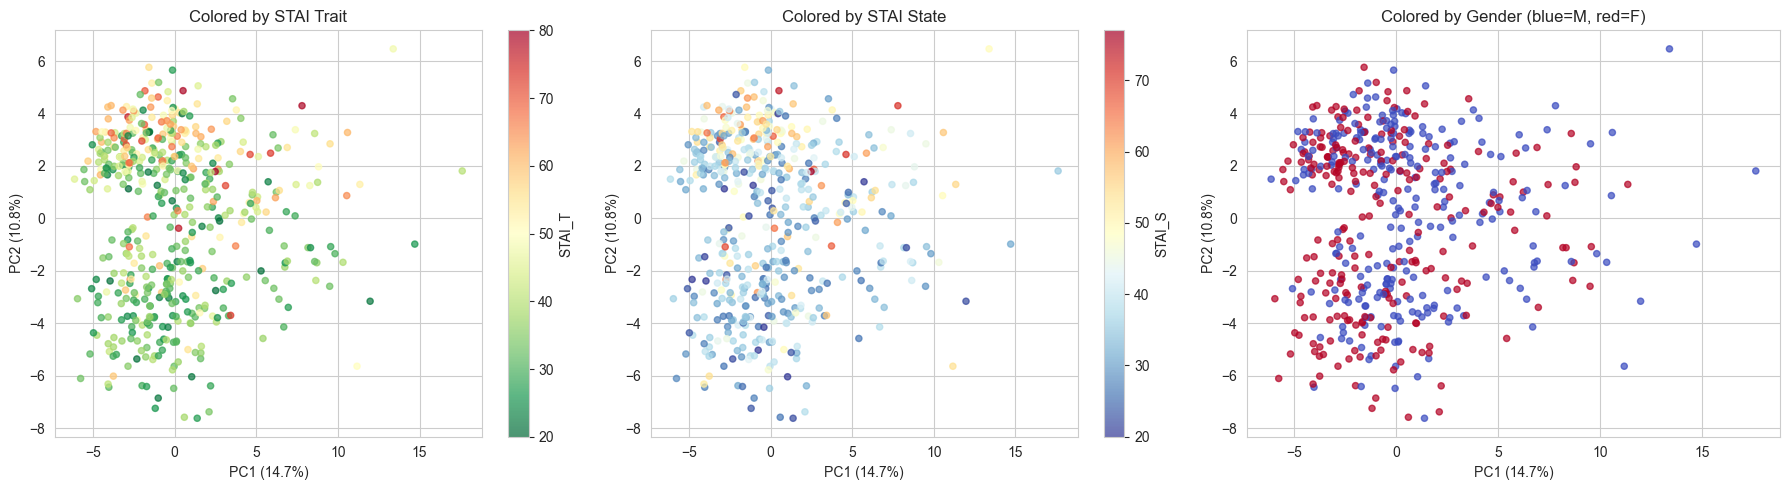

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Color by STAI_T
sc0 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=metadata["STAI_T"], cmap="RdYlGn_r", s=20, alpha=0.7)
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].set_title("Colored by STAI Trait")
plt.colorbar(sc0, ax=axes[0], label="STAI_T")

# Color by STAI_S
sc1 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=metadata["STAI_S"], cmap="RdYlBu_r", s=20, alpha=0.7)
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].set_title("Colored by STAI State")
plt.colorbar(sc1, ax=axes[1], label="STAI_S")

# Color by Gender
gender_num = metadata["Gender"].map({"M": 0, "F": 1})
sc2 = axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=gender_num, cmap="coolwarm", s=20, alpha=0.7)
axes[2].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[2].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[2].set_title("Colored by Gender (blue=M, red=F)")

plt.tight_layout()
plt.show()

## 6. Loadings

In [22]:
# Build loadings DataFrame: rows = features, columns = PCs
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

print("Loadings shape:", loadings.shape)
loadings.head(10)

Loadings shape: (90, 23)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23
PupilMean,0.086132,0.177350,-0.112793,0.240093,-0.053182,-0.035605,-0.116634,0.032371,0.030876,0.010010,...,0.026518,0.032392,-0.046885,-0.019477,0.010325,-0.025397,0.022778,0.010513,0.006543,-0.004230
PupilStd,0.131403,-0.117667,-0.054421,0.168438,-0.046777,-0.125445,0.110168,0.008106,-0.114947,0.026175,...,0.054201,-0.057701,0.112260,0.122404,-0.073087,0.050030,-0.192135,-0.030617,-0.109911,0.070480
PupilIQR,0.107040,-0.123664,-0.051540,0.164581,-0.057526,-0.130273,0.082867,0.020447,-0.117405,0.014552,...,0.022185,-0.045230,0.118652,0.112519,-0.105734,0.081579,-0.183605,-0.046874,-0.089414,0.068407
PulseMean,-0.036044,-0.010489,0.320081,0.162296,0.048013,-0.084702,-0.003467,-0.029472,0.018420,-0.010428,...,-0.003659,0.010148,0.006170,-0.012770,0.027084,0.003493,0.030563,-0.005322,0.007264,-0.020086
PulseStd,-0.043800,0.008925,-0.009194,0.008915,-0.075659,0.036355,-0.041494,-0.108603,0.016727,-0.376136,...,-0.037883,-0.063952,0.015194,0.096133,-0.125360,0.076539,0.070867,-0.088976,-0.148334,0.000013
PulseIQR,-0.026753,0.009623,-0.025332,-0.005604,-0.074457,0.033419,-0.033214,-0.089625,0.106841,-0.282518,...,-0.046432,-0.074000,-0.036608,0.080640,-0.192950,0.146741,0.040758,-0.049728,0.030258,0.007217
GazeXMean,0.067814,-0.053718,0.088660,0.081140,-0.111785,0.337326,0.027574,0.093358,-0.028408,0.023499,...,0.051520,-0.050083,-0.073635,0.001210,-0.022239,-0.046592,-0.044859,0.008627,0.009958,-0.048549
GazeXSpread,0.131369,-0.002687,0.006424,-0.046748,0.048535,-0.004700,-0.044259,-0.061652,0.182621,0.014487,...,0.383964,-0.060469,0.130268,0.065556,0.248010,0.109886,0.027062,0.248246,-0.023799,-0.126543
GazeXIQR,0.105052,0.001164,0.001216,-0.058227,0.052965,-0.016612,-0.056076,-0.036398,0.183151,0.021400,...,0.401093,-0.064671,0.129606,0.102864,0.258977,0.146447,0.025475,0.264434,-0.043347,-0.157254
GazeYMean,-0.036348,0.005386,-0.084180,0.122532,0.303070,0.151888,0.090153,-0.094370,-0.026574,-0.045090,...,-0.035828,0.008841,0.098476,-0.058219,0.008514,0.028748,0.011557,-0.030455,-0.088200,-0.069373


### Top 15 loadings for PC1 and PC2

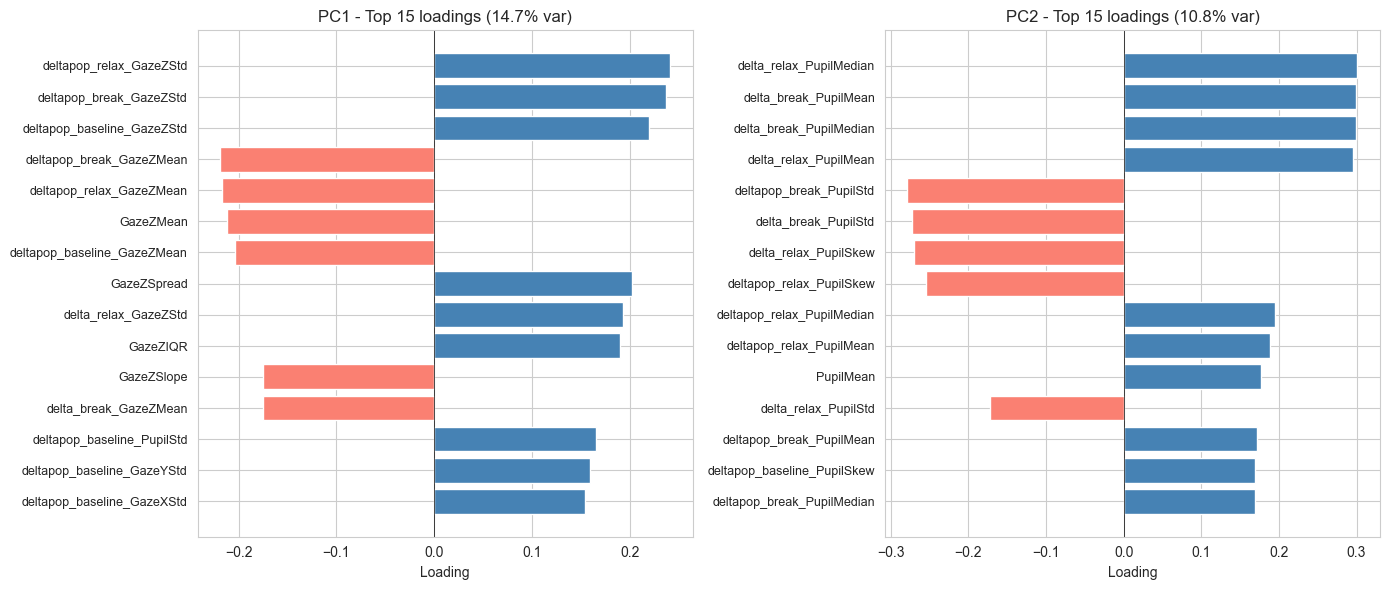

In [23]:
n_top = 15

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, ax in enumerate(axes):
    pc = f"PC{i+1}"
    top = loadings[pc].abs().nlargest(n_top).index
    vals = loadings.loc[top, pc]
    colors = ["steelblue" if v > 0 else "salmon" for v in vals]

    ax.barh(range(len(vals)), vals.values, color=colors)
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels(vals.index, fontsize=9)
    ax.set_xlabel("Loading")
    ax.set_title(f"{pc} - Top {n_top} loadings ({pca.explained_variance_ratio_[i]*100:.1f}% var)")
    ax.axvline(0, color="black", linewidth=0.5)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

#### Feature loadings in PC1-PC2 space

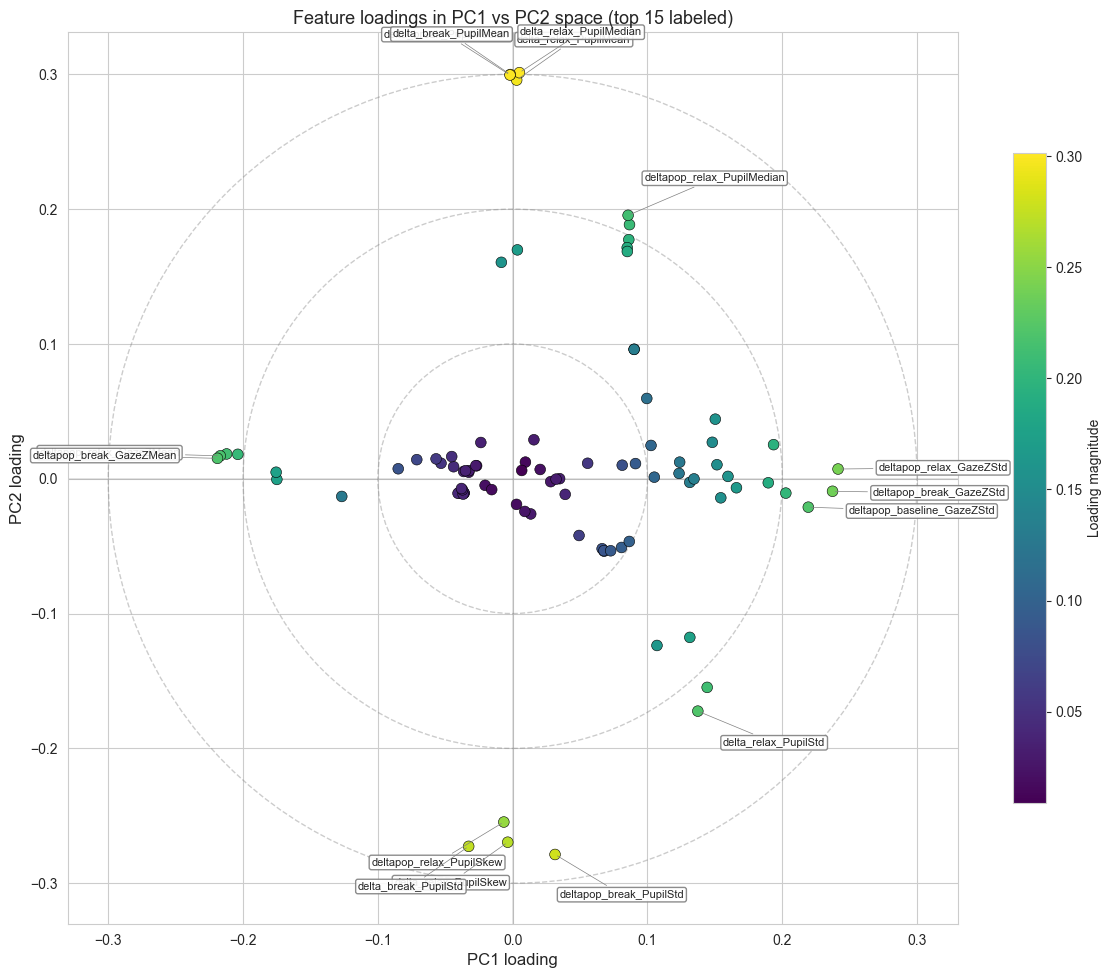

In [25]:
lx = loadings["PC1"].values
ly = loadings["PC2"].values
names = loadings.index.tolist()
magnitude = np.sqrt(lx**2 + ly**2)

fig, ax = plt.subplots(figsize=(12, 10))

# All features as dots
sc = ax.scatter(lx, ly, c=magnitude, cmap="viridis", s=60,
                edgecolors="black", linewidths=0.4, zorder=3)
plt.colorbar(sc, ax=ax, label="Loading magnitude", shrink=0.7)

# Reference circles
for r in [0.1, 0.2, 0.3]:
    circle = plt.Circle((0, 0), r, fill=False, linestyle="--", color="grey", alpha=0.4)
    ax.add_patch(circle)

# Label top 15 by magnitude
n_label = 15
top_idx = np.argsort(magnitude)[-n_label:]

for idx in top_idx:
    x, y = lx[idx], ly[idx]
    name = names[idx]

    # Push label outward so it doesn't sit on the dot
    dist = magnitude[idx]
    nudge = 0.03
    tx = x + (x / dist) * nudge if dist > 0 else x + nudge
    ty = y + (y / dist) * nudge if dist > 0 else y + nudge
    ha = "left" if x >= 0 else "right"

    ax.annotate(
        name, xy=(x, y), xytext=(tx, ty),
        fontsize=8, ha=ha, va="center",
        arrowprops=dict(arrowstyle="-", color="grey", lw=0.5),
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="grey", alpha=0.9),
    )

ax.set_xlabel("PC1 loading", fontsize=12)
ax.set_ylabel("PC2 loading", fontsize=12)
ax.set_title("Feature loadings in PC1 vs PC2 space (top 15 labeled)", fontsize=13)
ax.axhline(0, color="grey", linewidth=0.3)
ax.axvline(0, color="grey", linewidth=0.3)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 8. Correlation of PCs with STAI


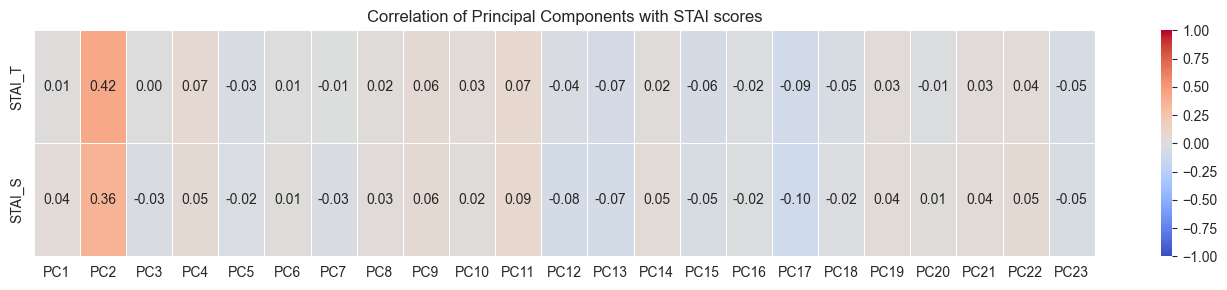

In [26]:
pc_df = pd.DataFrame(X_pca, index=X.index, columns=[f"PC{i+1}" for i in range(pca.n_components_)])
pc_df = pc_df.join(metadata[["STAI_T", "STAI_S"]])

pc_corr = pc_df.corr().loc[["STAI_T", "STAI_S"], [f"PC{i+1}" for i in range(pca.n_components_)]]

fig, ax = plt.subplots(figsize=(max(8, pca.n_components_ * 0.6), 3))
sns.heatmap(pc_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("Correlation of Principal Components with STAI scores")
plt.tight_layout()
plt.show()